<a href="https://colab.research.google.com/github/wetherc/data-2000/blob/sp26/labs/070_convolutional-networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flower Species Classification

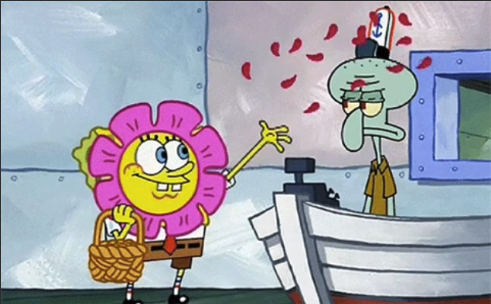

In this lab, we will be training a convolutional neural network to correctly classify flowers into one of 5 different species. We'll be using all the same concepts that we discussed in class on Tuesday, as well as introducing several new ones throughout the lab here

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

### Download and explore the dataset

This tutorial uses a dataset of about 3,700 photos of flowers. The dataset contains five sub-directories, one per class:

```
flower_photo/
  daisy/
  dandelion/
  roses/
  sunflowers/
  tulips/
```

In [2]:
!wget --no-check-certificate \
    https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz \
    -O /tmp/flowers.tgz

--2026-04-10 12:29:40--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.125.207, 142.251.183.207, 209.85.200.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.125.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘/tmp/flowers.tgz’

/tmp/flowers.tgz    100%[===================>] 218.21M   169MB/s    in 1.3s    

2026-04-10 12:29:41 (169 MB/s) - ‘/tmp/flowers.tgz’ saved [228813984/228813984]



After downloading our data, we will need to unzip it (or untar it in this case). After this, we can take a look at the number of classes represented for each flower in our dataset

In [3]:
import tarfile
import os

tar = tarfile.open('/tmp/flowers.tgz', 'r:gz')
tar.extractall('/tmp')
tar.close()

base_dir = '/tmp/flower_photos'

classes = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

# Directories with our training pictures
train_dirs = dict([(flower, os.path.join(base_dir, flower)) for flower in classes])
train_dirs

/tmp/ipykernel_2680/1362808772.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/tmp')


{'daisy': '/tmp/flower_photos/daisy',
 'dandelion': '/tmp/flower_photos/dandelion',
 'roses': '/tmp/flower_photos/roses',
 'sunflowers': '/tmp/flower_photos/sunflowers',
 'tulips': '/tmp/flower_photos/tulips'}

In [4]:
for flower, path in train_dirs.items():
    print(f'total training {flower} images:', len(os.listdir(path)))

total training daisy images: 633
total training dandelion images: 898
total training roses images: 641
total training sunflowers images: 699
total training tulips images: 799


## Ingest our image data

In the example from our last lab on feed forward networks, we were working with tabular data loaded as Panda dataframes. Because we're now working with image data, we will use a slightly different method for loading them in a way that Tensorflow is able to understand. Notably, here we are calling the `image_dataset_from_directory()` function and returning a tuple of training and validation datasets.

For full documentation on this function, refer to the [Tensorflow Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory)

In [5]:
import tensorflow as tf

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
  base_dir,
  validation_split=0.2,
  subset="both",
  seed=123,
  image_size=(180, 180),
  batch_size=20)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Using 734 files for validation.


Although we see in the output above that Tensorflow found 5 unique classes, we can verify what the discovered class labels are:

In [6]:
class_names = train_ds.class_names
class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Finally, we can display a handful of images to get a sense for what we'll be trying to correctly classify:

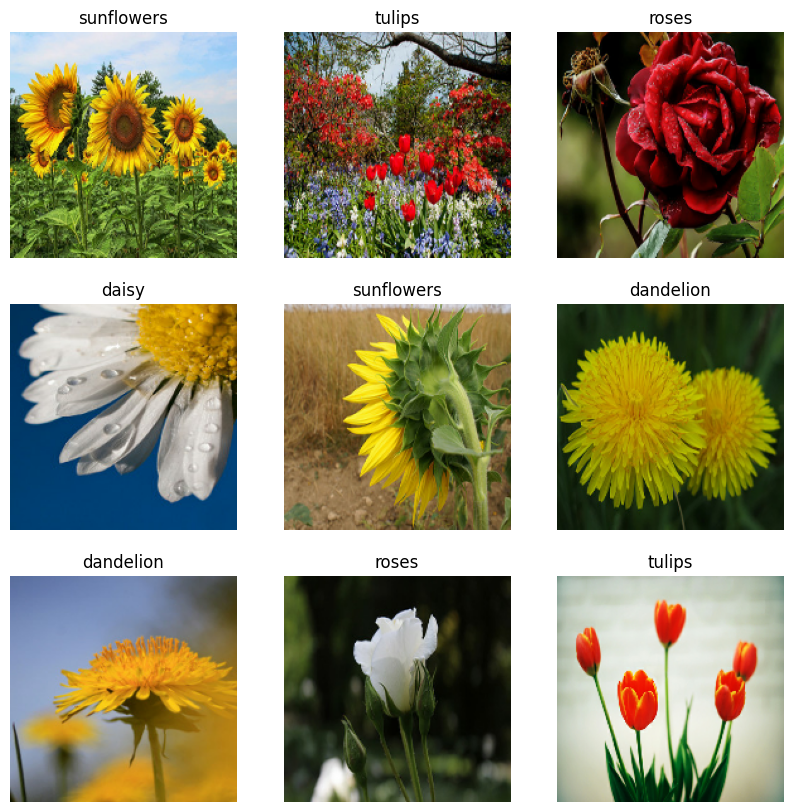

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

## Building a Small Convnet from Scratch to Get to >50% Accuracy

The images that will go into our convnet are 180x180 color images (in the next section on Data Preprocessing, we'll add handling to resize all the images to 180x180 before feeding them into the neural network).

Let's code up the architecture. We will stack 3 {convolution + relu + maxpooling} modules. Our convolutions operate on 3x3 windows and our maxpooling layers operate on 2x2 windows. Our first convolution extracts 16 filters, the following one extracts 32 filters, and the last one extracts 64 filters.

**NOTE**: This is a configuration that is widely used and known to work well for image classification. Also, since we have relatively few training examples (3,000), using just three convolutional modules keeps the model small, which lowers the risk of overfitting (which we'll explore in more depth in Exercise 2.)

In [8]:
from tensorflow.keras import layers
from tensorflow.keras import Model

In [9]:
img_input = layers.Input(shape=(180, 180, 3))

rescaled_input = layers.Rescaling(1./255)(img_input)

# First convolution extracts 16 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(16, 3, activation='relu')(img_input)
x = layers.MaxPooling2D(2)(x)

# Second convolution extracts 32 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

# Third convolution extracts 64 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

In [10]:
# Flatten feature map to a 1-dim tensor so we can add fully connected layers
x = layers.Flatten()(x)

# Create a fully connected layer with ReLU activation and 512 hidden units
x = layers.Dense(512, activation='relu')(x)

x = layers.Dense(256, activation='relu')(x)

# Create output layer with a single node and softmax activation
output = layers.Dense(len(class_names), activation="softmax")(x)

# Create model:
# input = input feature map
# output = input feature map + stacked convolution/maxpooling layers + fully
# connected layer + sigmoid output layer
model = Model(img_input, output)

Let's summarize the model architecture:

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,263,909 (50.60 MB)

 Trainable params: 13,263,909 (50.60 MB)

 Non-trainable params: 0 (0.00 B)

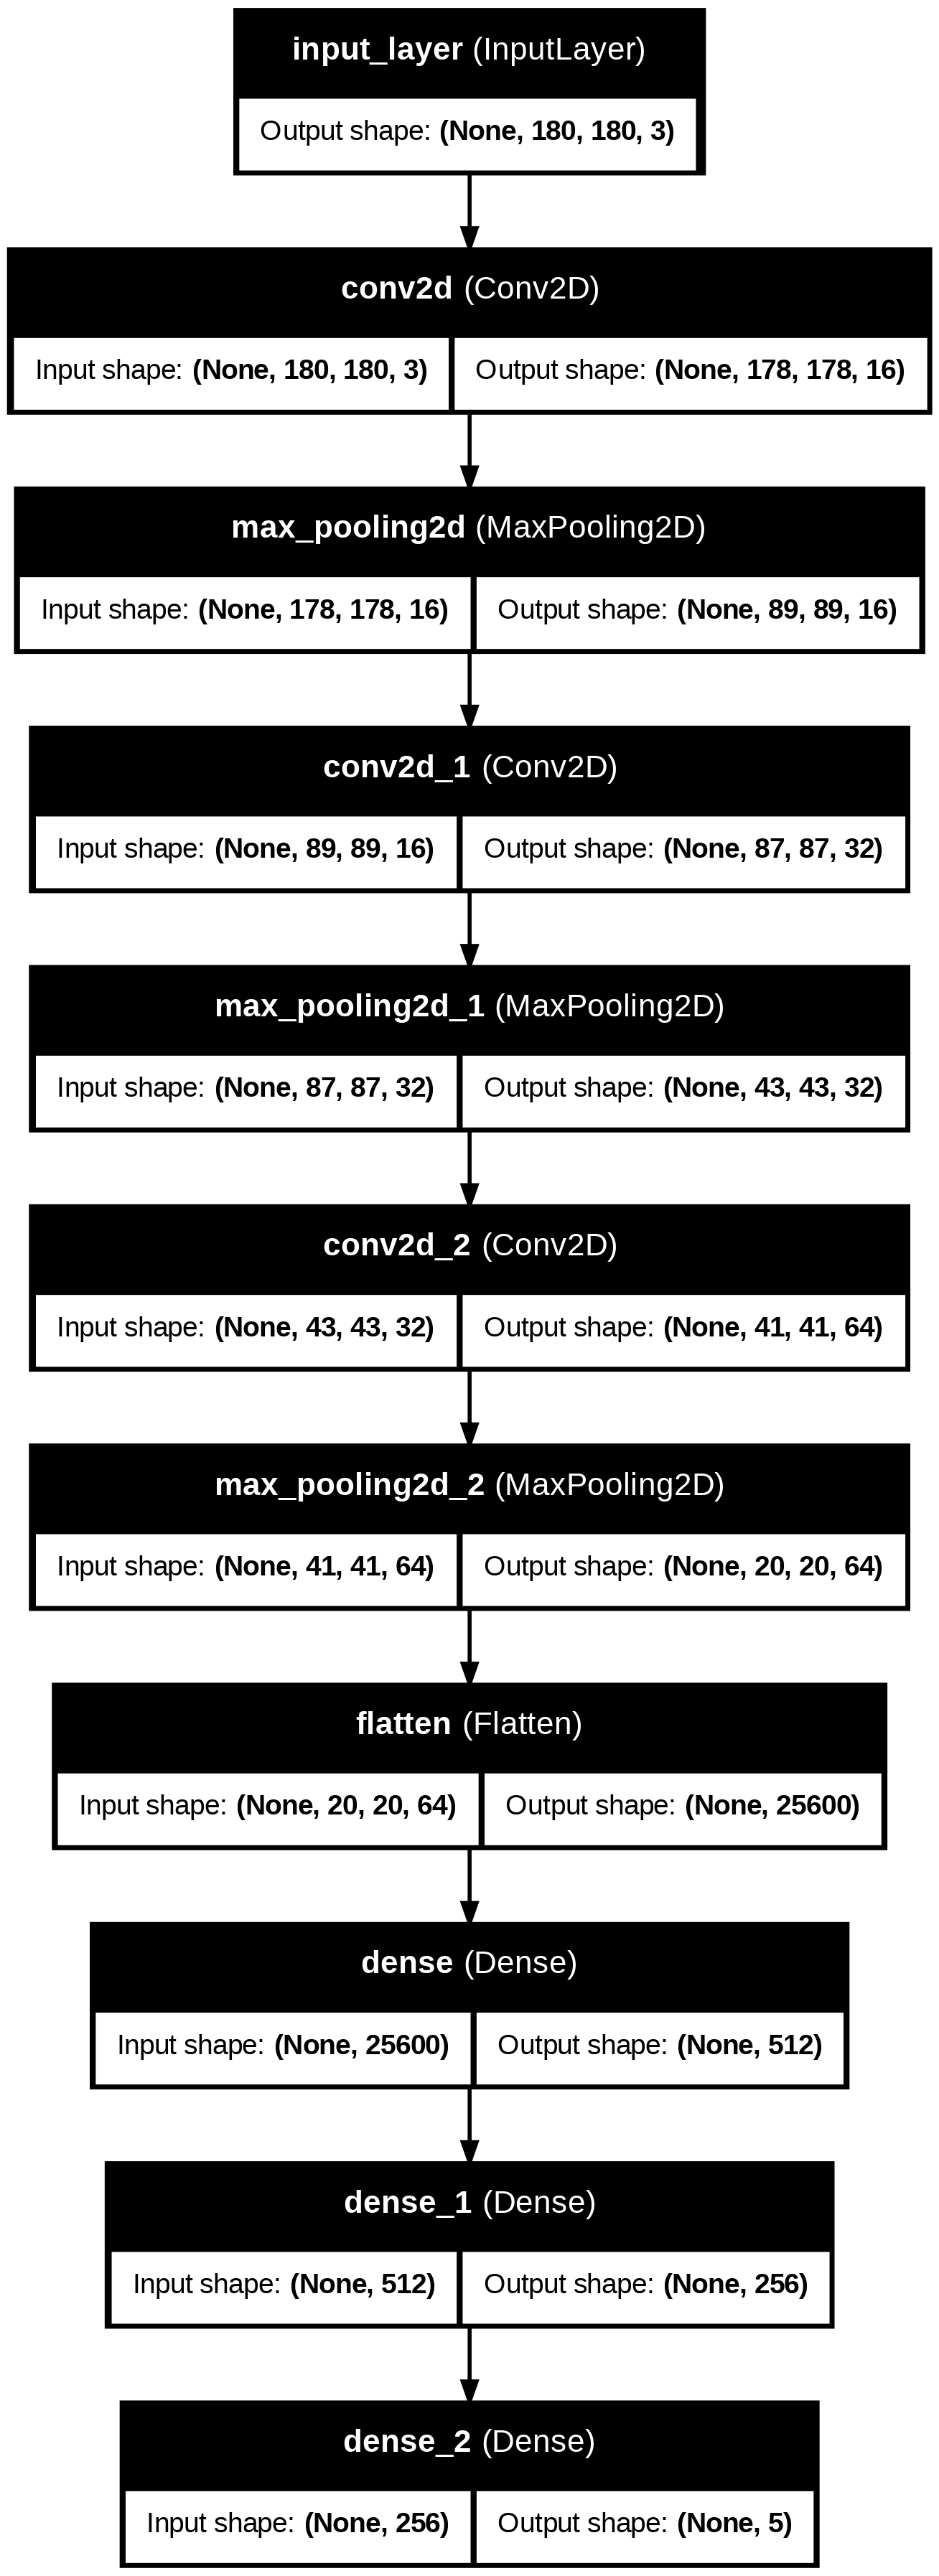

In [12]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

The "output shape" column shows how the size of your feature map evolves in each successive layer. The convolution layers reduce the size of the feature maps by a bit due to padding, and each pooling layer halves the feature map.

Next, we'll configure the specifications for model training. We will train our model with the `categorical_crossentropy` loss, because it's a multi-class classification problem and our final activation is a softmax. (For a refresher on loss metrics, see the [Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course/descending-into-ml/video-lecture).) We will use the `rmsprop` optimizer with a learning rate of `0.001`. During training, we will want to monitor classification accuracy.

**NOTE**: In this case, using the [RMSprop optimization algorithm](https://wikipedia.org/wiki/Stochastic_gradient_descent#RMSProp) is preferable to [stochastic gradient descent](https://developers.google.com/machine-learning/glossary/#SGD) (SGD), because RMSprop automates learning-rate tuning for us. (Other optimizers, such as [Adam](https://wikipedia.org/wiki/Stochastic_gradient_descent#Adam) and [Adagrad](https://developers.google.com/machine-learning/glossary/#AdaGrad), also automatically adapt the learning rate during training, and would work equally well here.)

In [13]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

model.compile(
    loss=SparseCategoricalCrossentropy,
    optimizer=RMSprop(learning_rate=0.001),
    metrics=[SparseCategoricalAccuracy])

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    batch_size=128,
    epochs=50,
    shuffle=True,
    validation_data=val_ds,
    callbacks=[early_stopping]
)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - loss: 36.6925 - sparse_categorical_accuracy: 0.2820 - val_loss: 1.5871 - val_sparse_categorical_accuracy: 0.2602
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.2944 - sparse_categorical_accuracy: 0.3134 - val_loss: 1.6151 - val_sparse_categorical_accuracy: 0.2820
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.4733 - sparse_categorical_accuracy: 0.4169 - val_loss: 2.1682 - val_sparse_categorical_accuracy: 0.3229
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.2554 - sparse_categorical_accuracy: 0.5058 - val_loss: 2.0774 - val_sparse_categorical_accuracy: 0.2997
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5791 - sparse_categorical_accuracy: 0.6107 - val_loss: 2.2920 - val_sparse_categorical_accuracy: 0.3147
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.5694 - sparse_categorical_accuracy: 0.6465 - val_loss: 2.3127 - val_sparse_categorical_accuracy: 0.3433


### Visualizing Intermediate Representations

To get a feel for what kind of features our convnet has learned, one fun thing to do is to visualize how an input gets transformed as it goes through the convnet.

Let's pick a random image from the training set, and then generate a figure where each row is the output of a layer, and each image in the row is a specific filter in that output feature map. Rerun this cell to generate intermediate representations for a variety of training images.

In [15]:
import numpy as np
import random
import os
from tensorflow.keras.preprocessing.image import img_to_array, load_img

def pick_random_image():
    # Let's define a new Model that will take an image as input, and will output
    # intermediate representations for all layers in the previous model after
    # the first.
    successive_outputs = [layer.output for layer in model.layers[1:]]
    visualization_model = Model(model.input, successive_outputs)

    # Let's prepare a random input image of a flower from the training set.
    random_class = random.choice(classes)
    class_dir = train_dirs[random_class]
    random_image_file = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, random_image_file)
    print(img_path)

    img = load_img(img_path, target_size=(180, 180))  # this is a PIL image
    x = img_to_array(img)  # Numpy array with shape (180, 180, 3)
    x = x.reshape((1,) + x.shape)  # Numpy array with shape (1, 180, 180, 3)

    # Let's run our image through our network, thus obtaining all
    # intermediate representations for this image.
    successive_feature_maps = visualization_model.predict(x)

    # These are the names of the layers, so can have them as part of our plot
    layer_names = [layer.name for layer in model.layers[1:]]
    return layer_names, successive_feature_maps, x

/tmp/flower_photos/tulips/8690791226_b1f015259f_n.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step


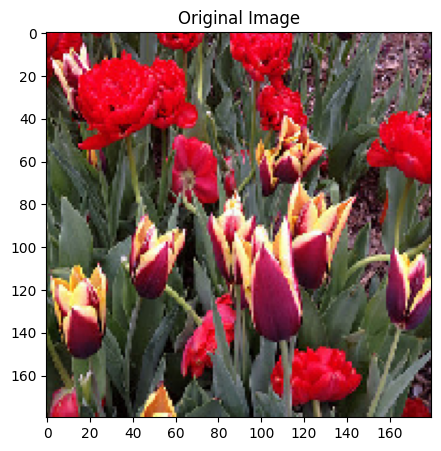

/tmp/ipykernel_2680/984094097.py:23: RuntimeWarning: invalid value encountered in divide
  filter_img /= filter_img.std()
/tmp/ipykernel_2680/984094097.py:26: RuntimeWarning: invalid value encountered in cast
  filter_img = np.clip(filter_img, 0, 255).astype('uint8')


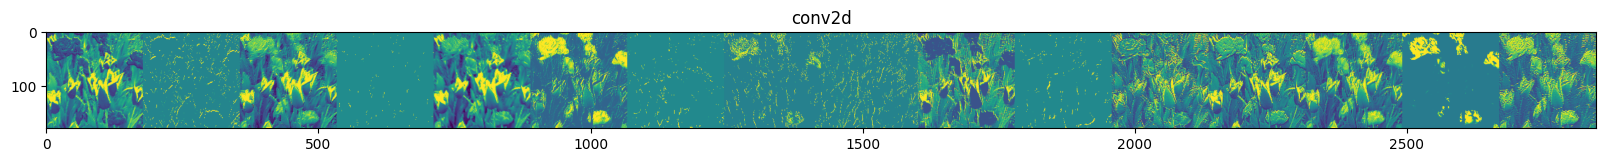

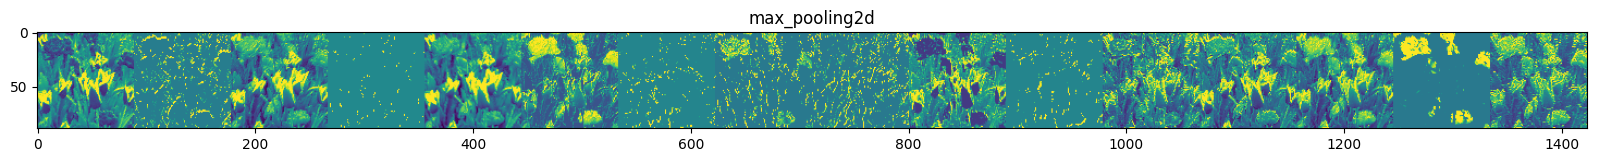

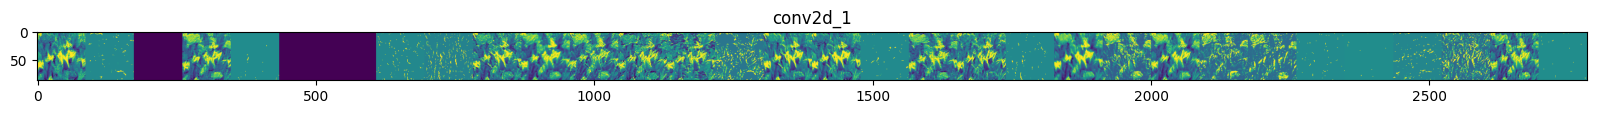

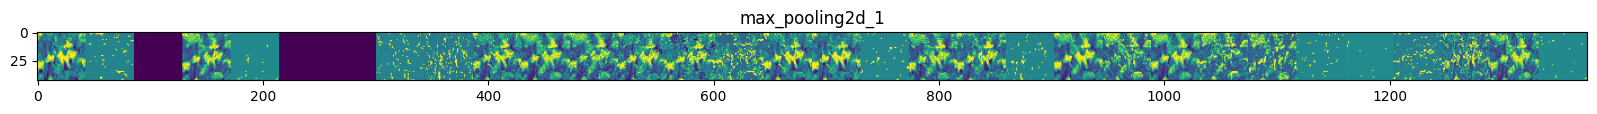

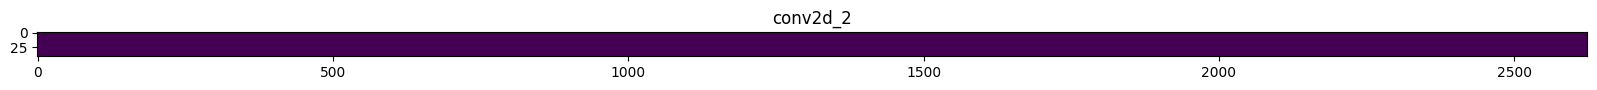

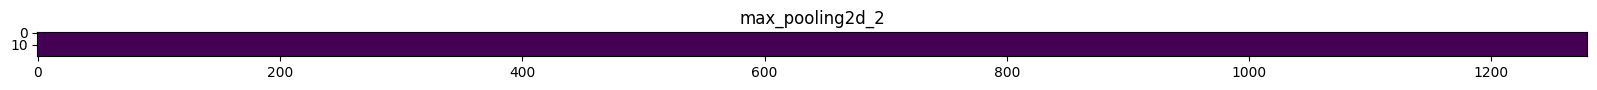

In [16]:
layer_names, successive_feature_maps, orig_img = pick_random_image()

# Display the original image
plt.figure(figsize=(5, 5))
plt.title("Original Image")
plt.grid(False)
plt.imshow(orig_img[0].astype('uint8'))
plt.show()

# Now let's display our representations
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
    if len(feature_map.shape) == 4:
        # Just do this for the conv / maxpool layers, not the fully-connected layers
        n_features = feature_map.shape[-1]  # number of features in feature map
        # The feature map has shape (1, size, size, n_features)
        size = feature_map.shape[1]
        # We will tile our images in this matrix
        display_grid = np.zeros((size, size * n_features))
        for i in range(n_features):
            # Postprocess the feature to make it visually palatable
            filter_img = feature_map[0, :, :, i]
            filter_img -= filter_img.mean()
            filter_img /= filter_img.std()
            filter_img *= 64
            filter_img += 128
            filter_img = np.clip(filter_img, 0, 255).astype('uint8')
            # We'll tile each filter into this big horizontal grid
            display_grid[:, i * size : (i + 1) * size] = filter_img
        # Display the grid
        scale = 20. / n_features
        plt.figure(figsize=(scale * n_features, scale))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')

As you can see we go from the raw pixels of the images to increasingly abstract and compact representations. The representations downstream start highlighting what the network pays attention to, and they show fewer and fewer features being "activated"; most are set to zero. This is called "sparsity." Representation sparsity is a key feature of deep learning.


These representations carry increasingly less information about the original pixels of the image, but increasingly refined information about the class of the image. You can think of a convnet (or a deep network in general) as an information distillation pipeline.

### Evaluating Accuracy and Loss for the Model

Let's plot the training/validation accuracy and loss as collected during training:

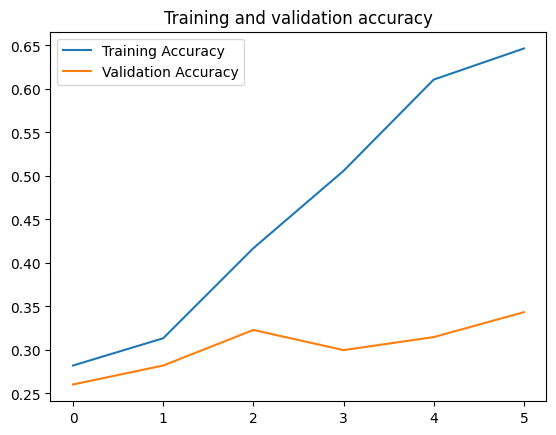

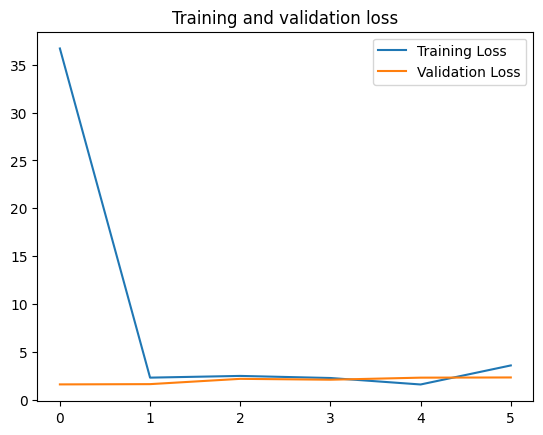

In [17]:
# Retrieve a list of accuracy results on training and validation data
# sets for each training epoch
acc = history.history['sparse_categorical_accuracy']
val_acc = history.history['val_sparse_categorical_accuracy']

# Retrieve a list of list results on training and validation data
# sets for each training epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and validation accuracy')

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and validation loss')
plt.show()

As you can see, we are **overfitting** like it's getting out of fashion. Our training accuracy (in blue) gets close to 90% (!) while our validation accuracy (in orange) stalls as 50%. Our validation loss reaches its minimum after only five or so epochs.

Since we have a relatively small number of training examples (3000), overfitting should be our number one concern. Overfitting happens when a model exposed to too few examples learns patterns that do not generalize to new data, i.e. when the model starts using irrelevant features for making predictions. For instance, if you, as a human, only see three images of people who are lumberjacks, and three images of people who are sailors, and among them the only person wearing a cap is a lumberjack, you might start thinking that wearing a cap is a sign of being a lumberjack as opposed to a sailor. You would then make a pretty lousy lumberjack/sailor classifier.

Overfitting is the central problem in machine learning: given that we are fitting the parameters of our model to a given dataset, how can we make sure that the representations learned by the model will be applicable to data never seen before? How do we avoid learning things that are specific to the training data?

In the next exercise, we'll look at ways to prevent overfitting in this classification model.


# Building a Better Classifier


Chances are, we've just built a model that does a really good job at memorizing flowers it's already seen, and only an okay job at IDing new flower photos. This is a common occurrence when we're training models, and there are a handful of ways we can try and mitigate this during training

## Dropout Layers

A dropout layer represents a step in our network where we just zero out some proportion of the neurons in that layer and pretend like they totally don't exist. This tends to have the effect of forcing our model to do a slightly better job of learning latent features that actually generalize well, and to minimize the relative weighting of features that just happen to jive well with data that it's memorized.

In Tensorflow, we use a Dropout layer to do this:

```python
from tensorflow.keras.layers import Dropout

dropout_layer = Dropout(0.2)(prior_layer)
```

This layer takes a single parameter, the proportion of neurons in the layer that we want to randomly ignore on each training pass. It's typical to set a value here somewhere between 20% and 50%, although the exact proportion will depend on the specifics of your use case and what just happens to work well in practice


## Image Augmentation

We can also add augmentations to our training images as part of our model graph. By doing things like applying crops, rotation, skew, shear, and so forth, we're able to increase the effective size of our training dataset.

Just like most other things in Tensorflow, there are layers for that! Tensorflow provides some built-in options for easy data augmentation that we can take advantage of here. There are also a number of tf.image methods that we can alternately use (Ref. Module: tf.image).

For example, to horizontally flip our images, and to rotate and zoom them, we can define these transformations in the same way we would any other layer in our model:

```python
flipped_input = layers.RandomFlip(
    "horizontal",
    input_shape=(180, 180, 3)
)(img_input)
rotated_input = layers.RandomRotation(0.1)(flipped_input)
zoomed_input = layers.RandomZoom(0.1)(rotated_input)
```

## Applying the Concepts

For this exercise, we will redefine our original model architecture so that it follows the following structure:

* Input layer
* Several image augmentation layers of your choosing. Valid options include:
  - RandomBrightness
  - RandomContrast
  - RandomCrop
  - RandomFlip
  - RandomHeight
  - RandomRotation
  - RandomTranslation
  - RandomWidth
  - RandomZoom
* The convolutional modules you defined in the prior part of the lab
* A dropout layer
* A flatten layer + your dense network both defined in the prior part of the lab

As before, we will evaluate our model's accuracy


In [18]:
from tensorflow.keras.layers import Dropout

img_input = layers.Input(shape=(180, 180, 3))

# Image augmentation layers
augmented_input = layers.RandomFlip("horizontal", input_shape=(180, 180, 3))(img_input)
augmented_input = layers.RandomRotation(0.1)(augmented_input)
augmented_input = layers.RandomZoom(0.1)(augmented_input)

# Rescale inputs
rescaled_input = layers.Rescaling(1./255)(augmented_input)

# First convolution extracts 16 filters that are 3x3
x = layers.Conv2D(16, 3, activation='relu')(rescaled_input)
x = layers.MaxPooling2D(2)(x)

# Second convolution extracts 32 filters that are 3x3
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

# Third convolution extracts 64 filters that are 3x3
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

# Flatten feature map to a 1-dim tensor
x = layers.Flatten()(x)

# Add a Dropout layer
x = layers.Dropout(0.5)(x)

# Create a fully connected layer with ReLU activation and 512 hidden units
x = layers.Dense(512, activation='relu')(x)

x = layers.Dense(256, activation='relu')(x)

# Create output layer with a single node and softmax activation
output = layers.Dense(len(class_names), activation="softmax")(x)

# Create the new model
model_augmented = Model(img_input, output)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model_augmented.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=RMSprop(learning_rate=0.001),
    metrics=[SparseCategoricalAccuracy()]
)

model_augmented.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,263,909 (50.60 MB)

 Trainable params: 13,263,909 (50.60 MB)

 Non-trainable params: 0 (0.00 B)

We've added augmentation layers like `RandomFlip`, `RandomRotation`, and `RandomZoom` to the input of our model. We also included a `Dropout` layer with a 50% dropout rate after the convolutional layers to further combat overfitting. Let's train this new model and see how it performs.

In [20]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_augmented = model_augmented.fit(
    train_ds,
    batch_size=128,
    epochs=50,
    shuffle=True,
    validation_data=val_ds,
    callbacks=[early_stopping]
)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.3663 - sparse_categorical_accuracy: 0.4230 - val_loss: 1.1955 - val_sparse_categorical_accuracy: 0.5095
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0669 - sparse_categorical_accuracy: 0.5763 - val_loss: 1.0869 - val_sparse_categorical_accuracy: 0.5777
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9849 - sparse_categorical_accuracy: 0.6223 - val_loss: 0.8784 - val_sparse_categorical_accuracy: 0.6390
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9081 - sparse_categorical_accuracy: 0.6597 - val_loss: 0.8499 - val_sparse_categorical_accuracy: 0.6744
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.8636 - sparse_categorical_accuracy: 0.6720 - val_loss: 0.8207 - val_sparse_categorical_accuracy: 0.6839
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8116 - sparse_categorical_accuracy: 0.6996 - val_loss: 0.9101 - val_sparse_categorical_accuracy: 0.670

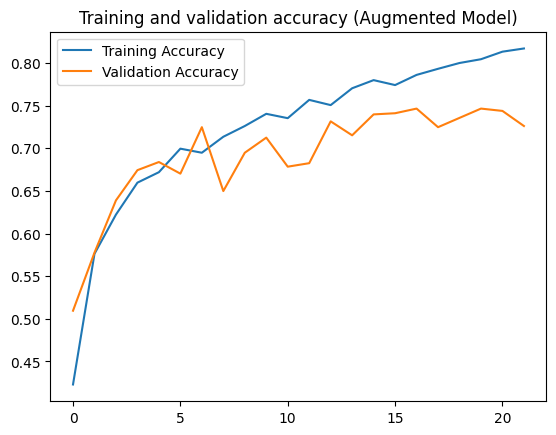

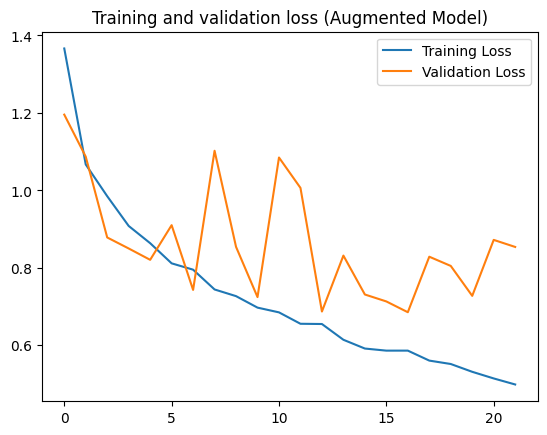

In [21]:
# Retrieve a list of accuracy results on training and validation data
# sets for each training epoch
acc = history_augmented.history['sparse_categorical_accuracy']
val_acc = history_augmented.history['val_sparse_categorical_accuracy']

# Retrieve a list of list results on training and validation data
# sets for each training epoch
loss = history_augmented.history['loss']
val_loss = history_augmented.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and validation accuracy (Augmented Model)')

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and validation loss (Augmented Model)')
plt.show()